In [2]:
# ============================================================
# CELL 1: Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# Verify data exists
data_path = '/content/drive/MyDrive/brain_tumor_project/processed'

if os.path.exists(data_path):
    print("✅ Data folder found!")
    for f in sorted(os.listdir(data_path)):
        size_mb = os.path.getsize(os.path.join(data_path, f)) / (1024*1024)
        print(f"  {f}: {size_mb:.1f} MB")
else:
    print("❌ Data folder NOT found!")
    print(f"Looked at: {data_path}")
    print("\nCheck your Google Drive structure.")
    print("It should be: My Drive/brain_tumor_project/processed/")

    # Try to find it
    base = '/content/drive/MyDrive'
    if os.path.exists(base):
        print(f"\nContents of My Drive:")
        for item in sorted(os.listdir(base))[:20]:
            print(f"  {item}")

Mounted at /content/drive
✅ Data folder found!
  metadata.pkl: 0.1 MB
  test_images.npy: 55.6 MB
  test_masks.npy: 55.6 MB
  train_images.npy: 248.3 MB
  train_masks.npy: 248.3 MB
  val_images.npy: 53.9 MB
  val_masks.npy: 53.9 MB


Loading data...
Loaded in 11.7 seconds

Train: (3972, 128, 128) images, (3972, 128, 128) masks
Val:   (863, 128, 128) images, (863, 128, 128) masks
Test:  (890, 128, 128) images, (890, 128, 128) masks

Image range: [0.0000, 0.9925]
Mask values: [0. 1.]


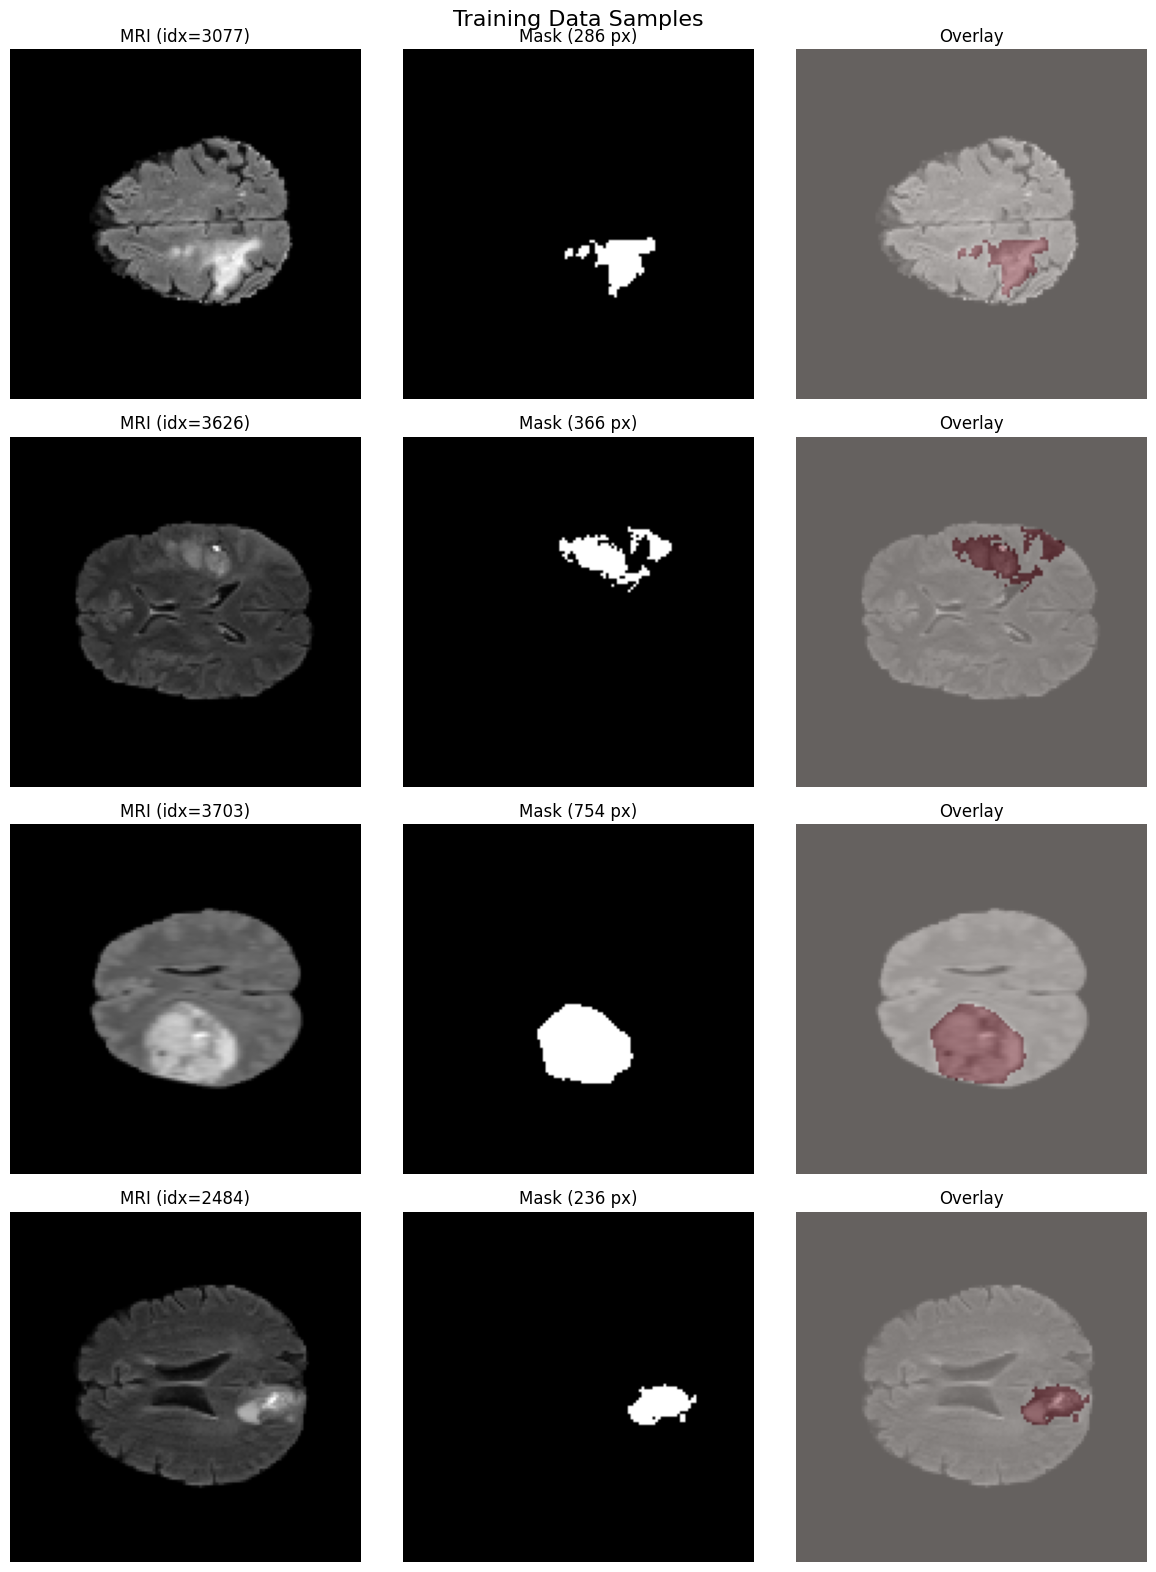


✅ Data loaded and verified!


In [3]:
# ============================================================
# CELL 2: Load Data and Verify
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import time

data_path = '/content/drive/MyDrive/brain_tumor_project/processed'

print("Loading data...")
start = time.time()

train_images = np.load(os.path.join(data_path, 'train_images.npy'))
train_masks = np.load(os.path.join(data_path, 'train_masks.npy'))
val_images = np.load(os.path.join(data_path, 'val_images.npy'))
val_masks = np.load(os.path.join(data_path, 'val_masks.npy'))
test_images = np.load(os.path.join(data_path, 'test_images.npy'))
test_masks = np.load(os.path.join(data_path, 'test_masks.npy'))

elapsed = time.time() - start
print(f"Loaded in {elapsed:.1f} seconds\n")

print(f"Train: {train_images.shape} images, {train_masks.shape} masks")
print(f"Val:   {val_images.shape} images, {val_masks.shape} masks")
print(f"Test:  {test_images.shape} images, {test_masks.shape} masks")
print(f"\nImage range: [{train_images.min():.4f}, {train_images.max():.4f}]")
print(f"Mask values: {np.unique(train_masks)}")

# Visualize samples
tumor_idx = np.where(train_masks.reshape(len(train_masks), -1).sum(axis=1) > 100)[0]
samples = np.random.choice(tumor_idx, min(4, len(tumor_idx)), replace=False)

fig, axes = plt.subplots(len(samples), 3, figsize=(12, 4*len(samples)))
for i, idx in enumerate(samples):
    axes[i, 0].imshow(train_images[idx], cmap='gray')
    axes[i, 0].set_title(f'MRI (idx={idx})')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(train_masks[idx], cmap='gray')
    axes[i, 1].set_title(f'Mask ({int(train_masks[idx].sum())} px)')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(train_images[idx], cmap='gray')
    axes[i, 2].imshow(train_masks[idx], cmap='Reds', alpha=0.4)
    axes[i, 2].set_title('Overlay')
    axes[i, 2].axis('off')

plt.suptitle('Training Data Samples', fontsize=16)
plt.tight_layout()
plt.show()

print("\n✅ Data loaded and verified!")

In [4]:
# ============================================================
# CELL 3: Dataset and DataLoader
# ============================================================
!pip install --upgrade albumentations # Add this line to update the library

import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# ============================================================
# Dataset class
# ============================================================
class BrainTumorDataset(Dataset):
    def __init__(self, images, masks, augment=False):
        self.images = images
        self.masks = masks
        self.augment = augment

        if augment:
            self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),
                A.Rotate(limit=15, p=0.5),
                A.RandomBrightnessContrast(
                    brightness_limit=0.1,
                    contrast_limit=0.1,
                    p=0.3
                ),
                A.GaussNoise(var_limit=(0.001, 0.005), p=0.2), # Reverted to GaussNoise to fix AttributeError
            ])
        else:
            self.transform = None

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].copy()
        mask = self.masks[idx].copy()

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Convert to tensors: (H, W) → (1, H, W)
        image = torch.FloatTensor(image).unsqueeze(0)
        mask = torch.FloatTensor(mask).unsqueeze(0)

        return image, mask

# ============================================================
# Create DataLoaders
# ============================================================
BATCH_SIZE = 16  # GPU can handle larger batches

train_dataset = BrainTumorDataset(train_images, train_masks, augment=True)
val_dataset = BrainTumorDataset(val_images, val_masks, augment=False)
test_dataset = BrainTumorDataset(test_images, test_masks, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Verify one batch
batch_img, batch_mask = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Images: {batch_img.shape}")   # Should be [16, 1, 128, 128]
print(f"  Masks:  {batch_mask.shape}")   # Should be [16, 1, 128, 128]
print(f"  Image range: [{batch_img.min():.4f}, {batch_img.max():.4f}]")
print(f"  Mask range:  [{batch_mask.min():.4f}, {batch_mask.max():.4f}]")

print(f"\nDataLoader sizes:")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val:   {len(val_loader)} batches")
print(f"  Test:  {len(test_loader)} batches")

print("\n✅ DataLoaders ready!")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 14.6 GB
Using device: cuda


/tmp/ipykernel_3328/4002954652.py:38: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(0.001, 0.005), p=0.2), # Reverted to GaussNoise to fix AttributeError



Batch shapes:
  Images: torch.Size([16, 1, 128, 128])
  Masks:  torch.Size([16, 1, 128, 128])
  Image range: [0.0000, 1.0000]
  Mask range:  [0.0000, 1.0000]

DataLoader sizes:
  Train: 249 batches
  Val:   54 batches
  Test:  56 batches

✅ DataLoaders ready!


In [5]:
# ============================================================
# CELL 4: U-Net Architecture
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    """Two consecutive Conv2D → BatchNorm → ReLU blocks"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class AttentionGate(nn.Module):
    """Attention Gate for focusing on relevant features"""
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class UNet(nn.Module):
    """Standard U-Net"""
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder (downsampling)
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder (upsampling)
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        # Final convolution
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]

            # Handle size mismatch
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)

            x = torch.cat((skip, x), dim=1)
            x = self.ups[idx + 1](x)

        return self.final_conv(x)


class AttentionUNet(nn.Module):
    """U-Net with Attention Gates"""
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.attentions = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        ch = in_channels
        for feature in features:
            self.downs.append(DoubleConv(ch, feature))
            ch = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder with attention
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.attentions.append(
                AttentionGate(F_g=feature, F_l=feature, F_int=feature // 2)
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]

            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)

            # Apply attention
            att_idx = idx // 2
            skip = self.attentions[att_idx](g=x, x=skip)

            x = torch.cat((skip, x), dim=1)
            x = self.ups[idx + 1](x)

        return self.final_conv(x)


# ============================================================
# Test both models
# ============================================================
print("Testing U-Net...")
model_unet = UNet(in_channels=1, out_channels=1, features=[64, 128, 256, 512])
test_input = torch.randn(2, 1, 128, 128)
test_output = model_unet(test_input)
print(f"  Input:  {test_input.shape}")
print(f"  Output: {test_output.shape}")

total_params = sum(p.numel() for p in model_unet.parameters())
trainable = sum(p.numel() for p in model_unet.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable: {trainable:,}")

print(f"\nTesting Attention U-Net...")
model_att = AttentionUNet(in_channels=1, out_channels=1, features=[64, 128, 256, 512])
test_output_att = model_att(test_input)
print(f"  Input:  {test_input.shape}")
print(f"  Output: {test_output_att.shape}")

total_params_att = sum(p.numel() for p in model_att.parameters())
print(f"  Total parameters: {total_params_att:,}")

print(f"\n✅ Both models working correctly!")
print(f"U-Net params: {total_params:,}")
print(f"Attention U-Net params: {total_params_att:,}")

Testing U-Net...
  Input:  torch.Size([2, 1, 128, 128])
  Output: torch.Size([2, 1, 128, 128])
  Total parameters: 31,036,481
  Trainable: 31,036,481

Testing Attention U-Net...
  Input:  torch.Size([2, 1, 128, 128])
  Output: torch.Size([2, 1, 128, 128])
  Total parameters: 31,388,013

✅ Both models working correctly!
U-Net params: 31,036,481
Attention U-Net params: 31,388,013


In [6]:
# ============================================================
# CELL 5: Loss Functions and Metrics
# ============================================================
import torch
import torch.nn as nn


class DiceLoss(nn.Module):
    """Dice Loss for segmentation"""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):
        predictions = torch.sigmoid(predictions)

        predictions = predictions.view(-1)
        targets = targets.view(-1)

        intersection = (predictions * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            predictions.sum() + targets.sum() + self.smooth
        )

        return 1 - dice


class DiceBCELoss(nn.Module):
    """Combined Dice + Binary Cross Entropy Loss"""
    def __init__(self, smooth=1.0, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice = DiceLoss(smooth)
        self.bce = nn.BCEWithLogitsLoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, predictions, targets):
        dice_loss = self.dice(predictions, targets)
        bce_loss = self.bce(predictions, targets)
        return self.dice_weight * dice_loss + self.bce_weight * bce_loss


def dice_coefficient(predictions, targets, threshold=0.5, smooth=1.0):
    """Calculate Dice Coefficient (metric, not loss)"""
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > threshold).float()

    predictions = predictions.view(-1)
    targets = targets.view(-1)

    intersection = (predictions * targets).sum()
    dice = (2. * intersection + smooth) / (
        predictions.sum() + targets.sum() + smooth
    )

    return dice.item()


def iou_score(predictions, targets, threshold=0.5, smooth=1.0):
    """Calculate IoU (Intersection over Union)"""
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > threshold).float()

    predictions = predictions.view(-1)
    targets = targets.view(-1)

    intersection = (predictions * targets).sum()
    union = predictions.sum() + targets.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou.item()


def pixel_accuracy(predictions, targets, threshold=0.5):
    """Calculate pixel-wise accuracy"""
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > threshold).float()

    correct = (predictions == targets).float().sum()
    total = targets.numel()

    return (correct / total).item()


def precision_score(predictions, targets, threshold=0.5, smooth=1.0):
    """Calculate Precision"""
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > threshold).float()

    predictions = predictions.view(-1)
    targets = targets.view(-1)

    tp = (predictions * targets).sum()
    fp = (predictions * (1 - targets)).sum()

    precision = (tp + smooth) / (tp + fp + smooth)
    return precision.item()


def recall_score(predictions, targets, threshold=0.5, smooth=1.0):
    """Calculate Recall / Sensitivity"""
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > threshold).float()

    predictions = predictions.view(-1)
    targets = targets.view(-1)

    tp = (predictions * targets).sum()
    fn = ((1 - predictions) * targets).sum()

    recall = (tp + smooth) / (tp + fn + smooth)
    return recall.item()


# Quick test
print("Testing loss functions and metrics...")
pred = torch.randn(4, 1, 128, 128)
target = torch.randint(0, 2, (4, 1, 128, 128)).float()

criterion = DiceBCELoss()
loss = criterion(pred, target)
dice = dice_coefficient(pred, target)
iou = iou_score(pred, target)
acc = pixel_accuracy(pred, target)
prec = precision_score(pred, target)
rec = recall_score(pred, target)

print(f"  Loss: {loss.item():.4f}")
print(f"  Dice: {dice:.4f}")
print(f"  IoU:  {iou:.4f}")
print(f"  Accuracy: {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall: {rec:.4f}")

print("\n✅ Loss functions and metrics ready!")

Testing loss functions and metrics...
  Loss: 0.6561
  Dice: 0.4970
  IoU:  0.3307
  Accuracy: 0.4986
  Precision: 0.4972
  Recall: 0.4968

✅ Loss functions and metrics ready!


In [7]:
# ============================================================
# CELL 6: COMPLETE TRAINING PIPELINE
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
import copy
import json

def train_model(model, train_loader, val_loader, config):
    """
    Complete training pipeline with:
    - Training loop
    - Validation after each epoch
    - Early stopping
    - Learning rate scheduling
    - Best model saving
    - Full metric tracking
    """

    model = model.to(DEVICE)
    criterion = DiceBCELoss(dice_weight=0.5, bce_weight=0.5)
    optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

    # Training history
    history = {
        'train_loss': [], 'val_loss': [],
        'train_dice': [], 'val_dice': [],
        'train_iou': [], 'val_iou': [],
        'lr': []
    }

    best_val_dice = 0.0
    best_model_state = None
    patience_counter = 0

    total_start = time.time()

    print("=" * 70)
    print(f"TRAINING: {config['model_name']}")
    print(f"Device: {DEVICE}")
    print(f"Epochs: {config['epochs']}")
    print(f"Batch Size: {config['batch_size']}")
    print(f"Learning Rate: {config['lr']}")
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")
    print("=" * 70)

    for epoch in range(config['epochs']):
        epoch_start = time.time()

        # ─────────────────────────────────────────────
        # TRAINING PHASE
        # ─────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        train_dice = 0.0
        train_iou = 0.0
        num_batches = 0

        for batch_idx, (images, masks) in enumerate(train_loader):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping (prevents exploding gradients)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            # Metrics
            train_loss += loss.item()
            train_dice += dice_coefficient(outputs, masks)
            train_iou += iou_score(outputs, masks)
            num_batches += 1

        avg_train_loss = train_loss / num_batches
        avg_train_dice = train_dice / num_batches
        avg_train_iou = train_iou / num_batches

        # ─────────────────────────────────────────────
        # VALIDATION PHASE
        # ─────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        val_dice = 0.0
        val_iou = 0.0
        num_val_batches = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item()
                val_dice += dice_coefficient(outputs, masks)
                val_iou += iou_score(outputs, masks)
                num_val_batches += 1

        avg_val_loss = val_loss / num_val_batches
        avg_val_dice = val_dice / num_val_batches
        avg_val_iou = val_iou / num_val_batches

        # Learning rate scheduling
        scheduler.step(avg_val_dice)
        current_lr = optimizer.param_groups[0]['lr']

        # Save history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_dice'].append(avg_train_dice)
        history['val_dice'].append(avg_val_dice)
        history['train_iou'].append(avg_train_iou)
        history['val_iou'].append(avg_val_iou)
        history['lr'].append(current_lr)

        epoch_time = time.time() - epoch_start

        # ─────────────────────────────────────────────
        # LOGGING
        # ─────────────────────────────────────────────
        improved = ""
        if avg_val_dice > best_val_dice:
            best_val_dice = avg_val_dice
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            improved = " ⭐ NEW BEST!"
        else:
            patience_counter += 1

        print(f"Epoch [{epoch+1:3d}/{config['epochs']}] "
              f"│ Train Loss: {avg_train_loss:.4f} Dice: {avg_train_dice:.4f} "
              f"│ Val Loss: {avg_val_loss:.4f} Dice: {avg_val_dice:.4f} IoU: {avg_val_iou:.4f} "
              f"│ LR: {current_lr:.6f} │ {epoch_time:.1f}s{improved}")

        # Early stopping
        if patience_counter >= config['patience']:
            print(f"\n⚠️  Early stopping at epoch {epoch+1} (no improvement for {config['patience']} epochs)")
            break

    total_time = time.time() - total_start

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"\n{'='*70}")
    print(f"TRAINING COMPLETE!")
    print(f"Total time: {total_time/60:.1f} minutes")
    print(f"Best Validation Dice: {best_val_dice:.4f}")
    print(f"{'='*70}")

    return model, history, best_val_dice


# ============================================================
# TRAIN U-NET
# ============================================================
unet_config = {
    'model_name': 'UNet',
    'epochs': 50,
    'batch_size': BATCH_SIZE,
    'lr': 1e-4,
    'weight_decay': 1e-5,
    'patience': 15
}

model_unet = UNet(in_channels=1, out_channels=1, features=[64, 128, 256, 512])

trained_unet, unet_history, unet_best_dice = train_model(
    model_unet, train_loader, val_loader, unet_config
)

print(f"\n🎯 U-Net Best Dice: {unet_best_dice:.4f}")

TRAINING: UNet
Device: cuda
Epochs: 50
Batch Size: 16
Learning Rate: 0.0001
Train batches: 249
Val batches: 54
Epoch [  1/50] │ Train Loss: 0.5750 Dice: 0.6537 │ Val Loss: 0.5045 Dice: 0.7169 IoU: 0.6019 │ LR: 0.000100 │ 55.6s ⭐ NEW BEST!
Epoch [  2/50] │ Train Loss: 0.4634 Dice: 0.7401 │ Val Loss: 0.4224 Dice: 0.6884 IoU: 0.5801 │ LR: 0.000100 │ 63.4s
Epoch [  3/50] │ Train Loss: 0.3773 Dice: 0.7615 │ Val Loss: 0.3505 Dice: 0.6931 IoU: 0.5945 │ LR: 0.000100 │ 70.9s
Epoch [  4/50] │ Train Loss: 0.2924 Dice: 0.7877 │ Val Loss: 0.2757 Dice: 0.7429 IoU: 0.6291 │ LR: 0.000100 │ 70.5s ⭐ NEW BEST!
Epoch [  5/50] │ Train Loss: 0.2199 Dice: 0.8092 │ Val Loss: 0.2221 Dice: 0.7794 IoU: 0.6812 │ LR: 0.000100 │ 70.0s ⭐ NEW BEST!
Epoch [  6/50] │ Train Loss: 0.1737 Dice: 0.8217 │ Val Loss: 0.2215 Dice: 0.7105 IoU: 0.6200 │ LR: 0.000100 │ 70.2s
Epoch [  7/50] │ Train Loss: 0.1440 Dice: 0.8317 │ Val Loss: 0.1800 Dice: 0.7531 IoU: 0.6535 │ LR: 0.000100 │ 69.8s
Epoch [  8/50] │ Train Loss: 0.1248 Dice:

In [8]:
# ============================================================
# CELL 7: TRAIN ATTENTION U-NET
# ============================================================
att_config = {
    'model_name': 'Attention_UNet',
    'epochs': 50,
    'batch_size': BATCH_SIZE,
    'lr': 1e-4,
    'weight_decay': 1e-5,
    'patience': 15
}

model_att = AttentionUNet(in_channels=1, out_channels=1, features=[64, 128, 256, 512])

trained_att, att_history, att_best_dice = train_model(
    model_att, train_loader, val_loader, att_config
)

print(f"\n🎯 Attention U-Net Best Dice: {att_best_dice:.4f}")
print(f"\n{'='*70}")
print(f"COMPARISON:")
print(f"  U-Net:           Dice = {unet_best_dice:.4f}")
print(f"  Attention U-Net: Dice = {att_best_dice:.4f}")
print(f"{'='*70}")

TRAINING: Attention_UNet
Device: cuda
Epochs: 50
Batch Size: 16
Learning Rate: 0.0001
Train batches: 249
Val batches: 54
Epoch [  1/50] │ Train Loss: 0.5861 Dice: 0.6621 │ Val Loss: 0.5061 Dice: 0.7239 IoU: 0.6026 │ LR: 0.000100 │ 78.8s ⭐ NEW BEST!
Epoch [  2/50] │ Train Loss: 0.4837 Dice: 0.7361 │ Val Loss: 0.4428 Dice: 0.6929 IoU: 0.5800 │ LR: 0.000100 │ 78.5s
Epoch [  3/50] │ Train Loss: 0.4026 Dice: 0.7572 │ Val Loss: 0.3637 Dice: 0.7449 IoU: 0.6339 │ LR: 0.000100 │ 78.4s ⭐ NEW BEST!
Epoch [  4/50] │ Train Loss: 0.3223 Dice: 0.7826 │ Val Loss: 0.2995 Dice: 0.7337 IoU: 0.6153 │ LR: 0.000100 │ 78.8s
Epoch [  5/50] │ Train Loss: 0.2492 Dice: 0.8008 │ Val Loss: 0.2456 Dice: 0.7535 IoU: 0.6506 │ LR: 0.000100 │ 78.7s ⭐ NEW BEST!
Epoch [  6/50] │ Train Loss: 0.1944 Dice: 0.8161 │ Val Loss: 0.1998 Dice: 0.7858 IoU: 0.6933 │ LR: 0.000100 │ 78.2s ⭐ NEW BEST!
Epoch [  7/50] │ Train Loss: 0.1589 Dice: 0.8270 │ Val Loss: 0.1876 Dice: 0.7743 IoU: 0.6676 │ LR: 0.000100 │ 79.1s
Epoch [  8/50] │ Tr

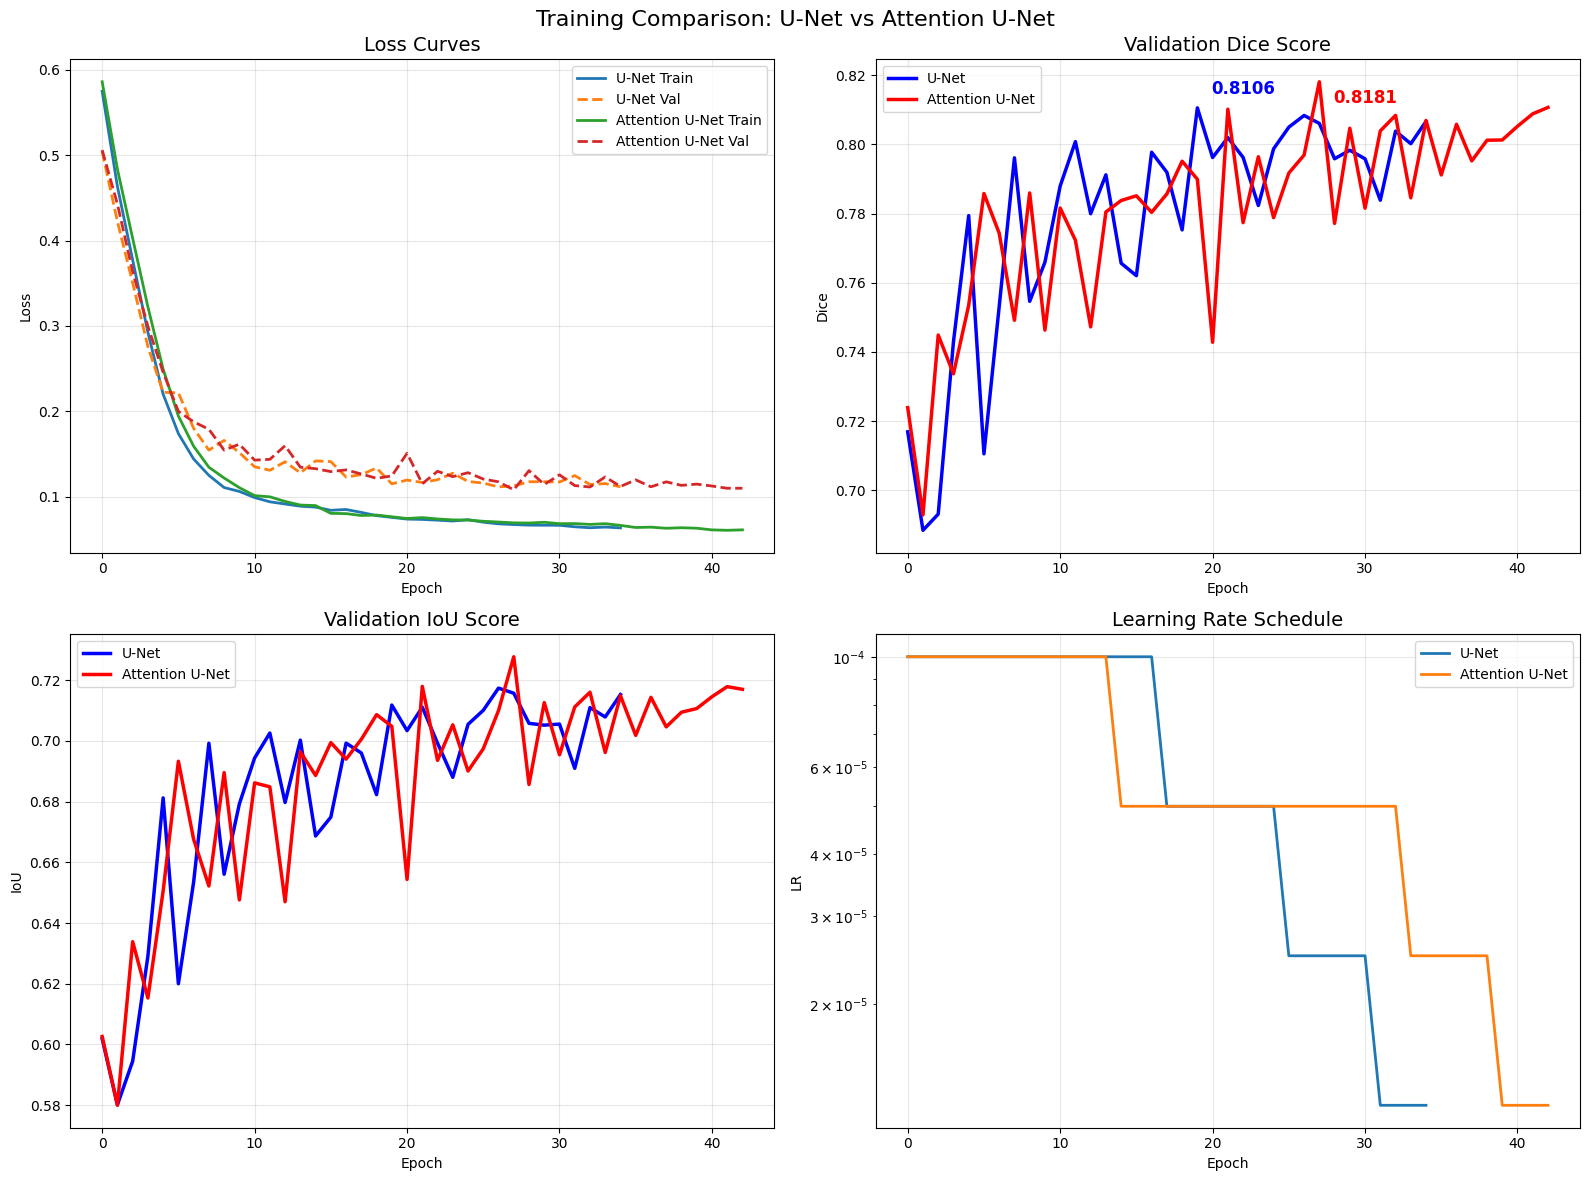

Saved: training_curves.png


In [9]:
# ============================================================
# CELL 8: TRAINING CURVES
# ============================================================
import matplotlib.pyplot as plt

def plot_training_history(history1, history2, name1='U-Net', name2='Attention U-Net'):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Training Loss
    axes[0, 0].plot(history1['train_loss'], label=f'{name1} Train', linewidth=2)
    axes[0, 0].plot(history1['val_loss'], label=f'{name1} Val', linewidth=2, linestyle='--')
    axes[0, 0].plot(history2['train_loss'], label=f'{name2} Train', linewidth=2)
    axes[0, 0].plot(history2['val_loss'], label=f'{name2} Val', linewidth=2, linestyle='--')
    axes[0, 0].set_title('Loss Curves', fontsize=14)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Validation Dice
    axes[0, 1].plot(history1['val_dice'], label=name1, linewidth=2.5, color='blue')
    axes[0, 1].plot(history2['val_dice'], label=name2, linewidth=2.5, color='red')
    axes[0, 1].set_title('Validation Dice Score', fontsize=14)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Dice')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Mark best dice
    best1 = max(history1['val_dice'])
    best1_epoch = history1['val_dice'].index(best1)
    axes[0, 1].annotate(f'{best1:.4f}', xy=(best1_epoch, best1),
                         fontsize=12, fontweight='bold', color='blue',
                         xytext=(10, 10), textcoords='offset points')

    best2 = max(history2['val_dice'])
    best2_epoch = history2['val_dice'].index(best2)
    axes[0, 1].annotate(f'{best2:.4f}', xy=(best2_epoch, best2),
                         fontsize=12, fontweight='bold', color='red',
                         xytext=(10, -15), textcoords='offset points')

    # Plot 3: Validation IoU
    axes[1, 0].plot(history1['val_iou'], label=name1, linewidth=2.5, color='blue')
    axes[1, 0].plot(history2['val_iou'], label=name2, linewidth=2.5, color='red')
    axes[1, 0].set_title('Validation IoU Score', fontsize=14)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('IoU')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Plot 4: Learning Rate
    axes[1, 1].plot(history1['lr'], label=name1, linewidth=2)
    axes[1, 1].plot(history2['lr'], label=name2, linewidth=2)
    axes[1, 1].set_title('Learning Rate Schedule', fontsize=14)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('LR')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_yscale('log')

    plt.suptitle('Training Comparison: U-Net vs Attention U-Net', fontsize=16)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/brain_tumor_project/training_curves.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved: training_curves.png")

plot_training_history(unet_history, att_history)

In [10]:
# ============================================================
# CELL 9: COMPREHENSIVE TEST SET EVALUATION
# ============================================================

def evaluate_model(model, test_loader, model_name="Model"):
    """Full evaluation with all metrics"""
    model.eval()
    model = model.to(DEVICE)

    all_dice = []
    all_iou = []
    all_precision = []
    all_recall = []
    all_accuracy = []

    all_predictions = []
    all_targets = []
    all_inputs = []

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)

            # Per-sample metrics
            for i in range(images.shape[0]):
                pred = outputs[i:i+1]
                target = masks[i:i+1]

                d = dice_coefficient(pred, target)
                io = iou_score(pred, target)
                p = precision_score(pred, target)
                r = recall_score(pred, target)
                a = pixel_accuracy(pred, target)

                all_dice.append(d)
                all_iou.append(io)
                all_precision.append(p)
                all_recall.append(r)
                all_accuracy.append(a)

            # Store for visualization
            all_predictions.append(torch.sigmoid(outputs).cpu())
            all_targets.append(masks.cpu())
            all_inputs.append(images.cpu())

    all_predictions = torch.cat(all_predictions)
    all_targets = torch.cat(all_targets)
    all_inputs = torch.cat(all_inputs)

    # Results
    results = {
        'dice_mean': np.mean(all_dice),
        'dice_std': np.std(all_dice),
        'iou_mean': np.mean(all_iou),
        'iou_std': np.std(all_iou),
        'precision_mean': np.mean(all_precision),
        'recall_mean': np.mean(all_recall),
        'accuracy_mean': np.mean(all_accuracy),
    }

    print(f"\n{'='*60}")
    print(f"TEST SET EVALUATION: {model_name}")
    print(f"{'='*60}")
    print(f"  Dice Coefficient: {results['dice_mean']:.4f} ± {results['dice_std']:.4f}")
    print(f"  IoU Score:        {results['iou_mean']:.4f} ± {results['iou_std']:.4f}")
    print(f"  Precision:        {results['precision_mean']:.4f}")
    print(f"  Recall:           {results['recall_mean']:.4f}")
    print(f"  Pixel Accuracy:   {results['accuracy_mean']:.4f}")
    print(f"  Samples tested:   {len(all_dice)}")
    print(f"{'='*60}")

    return results, all_predictions, all_targets, all_inputs, all_dice

# Evaluate both models
print("\n" + "🔬" * 30)
unet_results, unet_preds, unet_targets, unet_inputs, unet_dice_scores = evaluate_model(
    trained_unet, test_loader, "U-Net"
)

att_results, att_preds, att_targets, att_inputs, att_dice_scores = evaluate_model(
    trained_att, test_loader, "Attention U-Net"
)

# Comparison table
print(f"\n{'='*70}")
print(f"{'METRIC':<25} {'U-Net':<20} {'Attention U-Net':<20}")
print(f"{'='*70}")
for metric in ['dice_mean', 'iou_mean', 'precision_mean', 'recall_mean', 'accuracy_mean']:
    name = metric.replace('_mean', '').replace('_', ' ').title()
    v1 = unet_results[metric]
    v2 = att_results[metric]
    better = "←" if v1 > v2 else "→" if v2 > v1 else "="
    print(f"  {name:<23} {v1:.4f}              {v2:.4f}              {better}")
print(f"{'='*70}")

winner = "U-Net" if unet_results['dice_mean'] > att_results['dice_mean'] else "Attention U-Net"
print(f"\n🏆 Better model: {winner}")


🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬

TEST SET EVALUATION: U-Net
  Dice Coefficient: 0.7643 ± 0.2811
  IoU Score:        0.6884 ± 0.2967
  Precision:        0.8675
  Recall:           0.7729
  Pixel Accuracy:   0.9897
  Samples tested:   890

TEST SET EVALUATION: Attention U-Net
  Dice Coefficient: 0.7572 ± 0.2900
  IoU Score:        0.6826 ± 0.3009
  Precision:        0.8681
  Recall:           0.7725
  Pixel Accuracy:   0.9896
  Samples tested:   890

METRIC                    U-Net                Attention U-Net     
  Dice                    0.7643              0.7572              ←
  Iou                     0.6884              0.6826              ←
  Precision               0.8675              0.8681              →
  Recall                  0.7729              0.7725              ←
  Accuracy                0.9897              0.9896              ←

🏆 Better model: U-Net


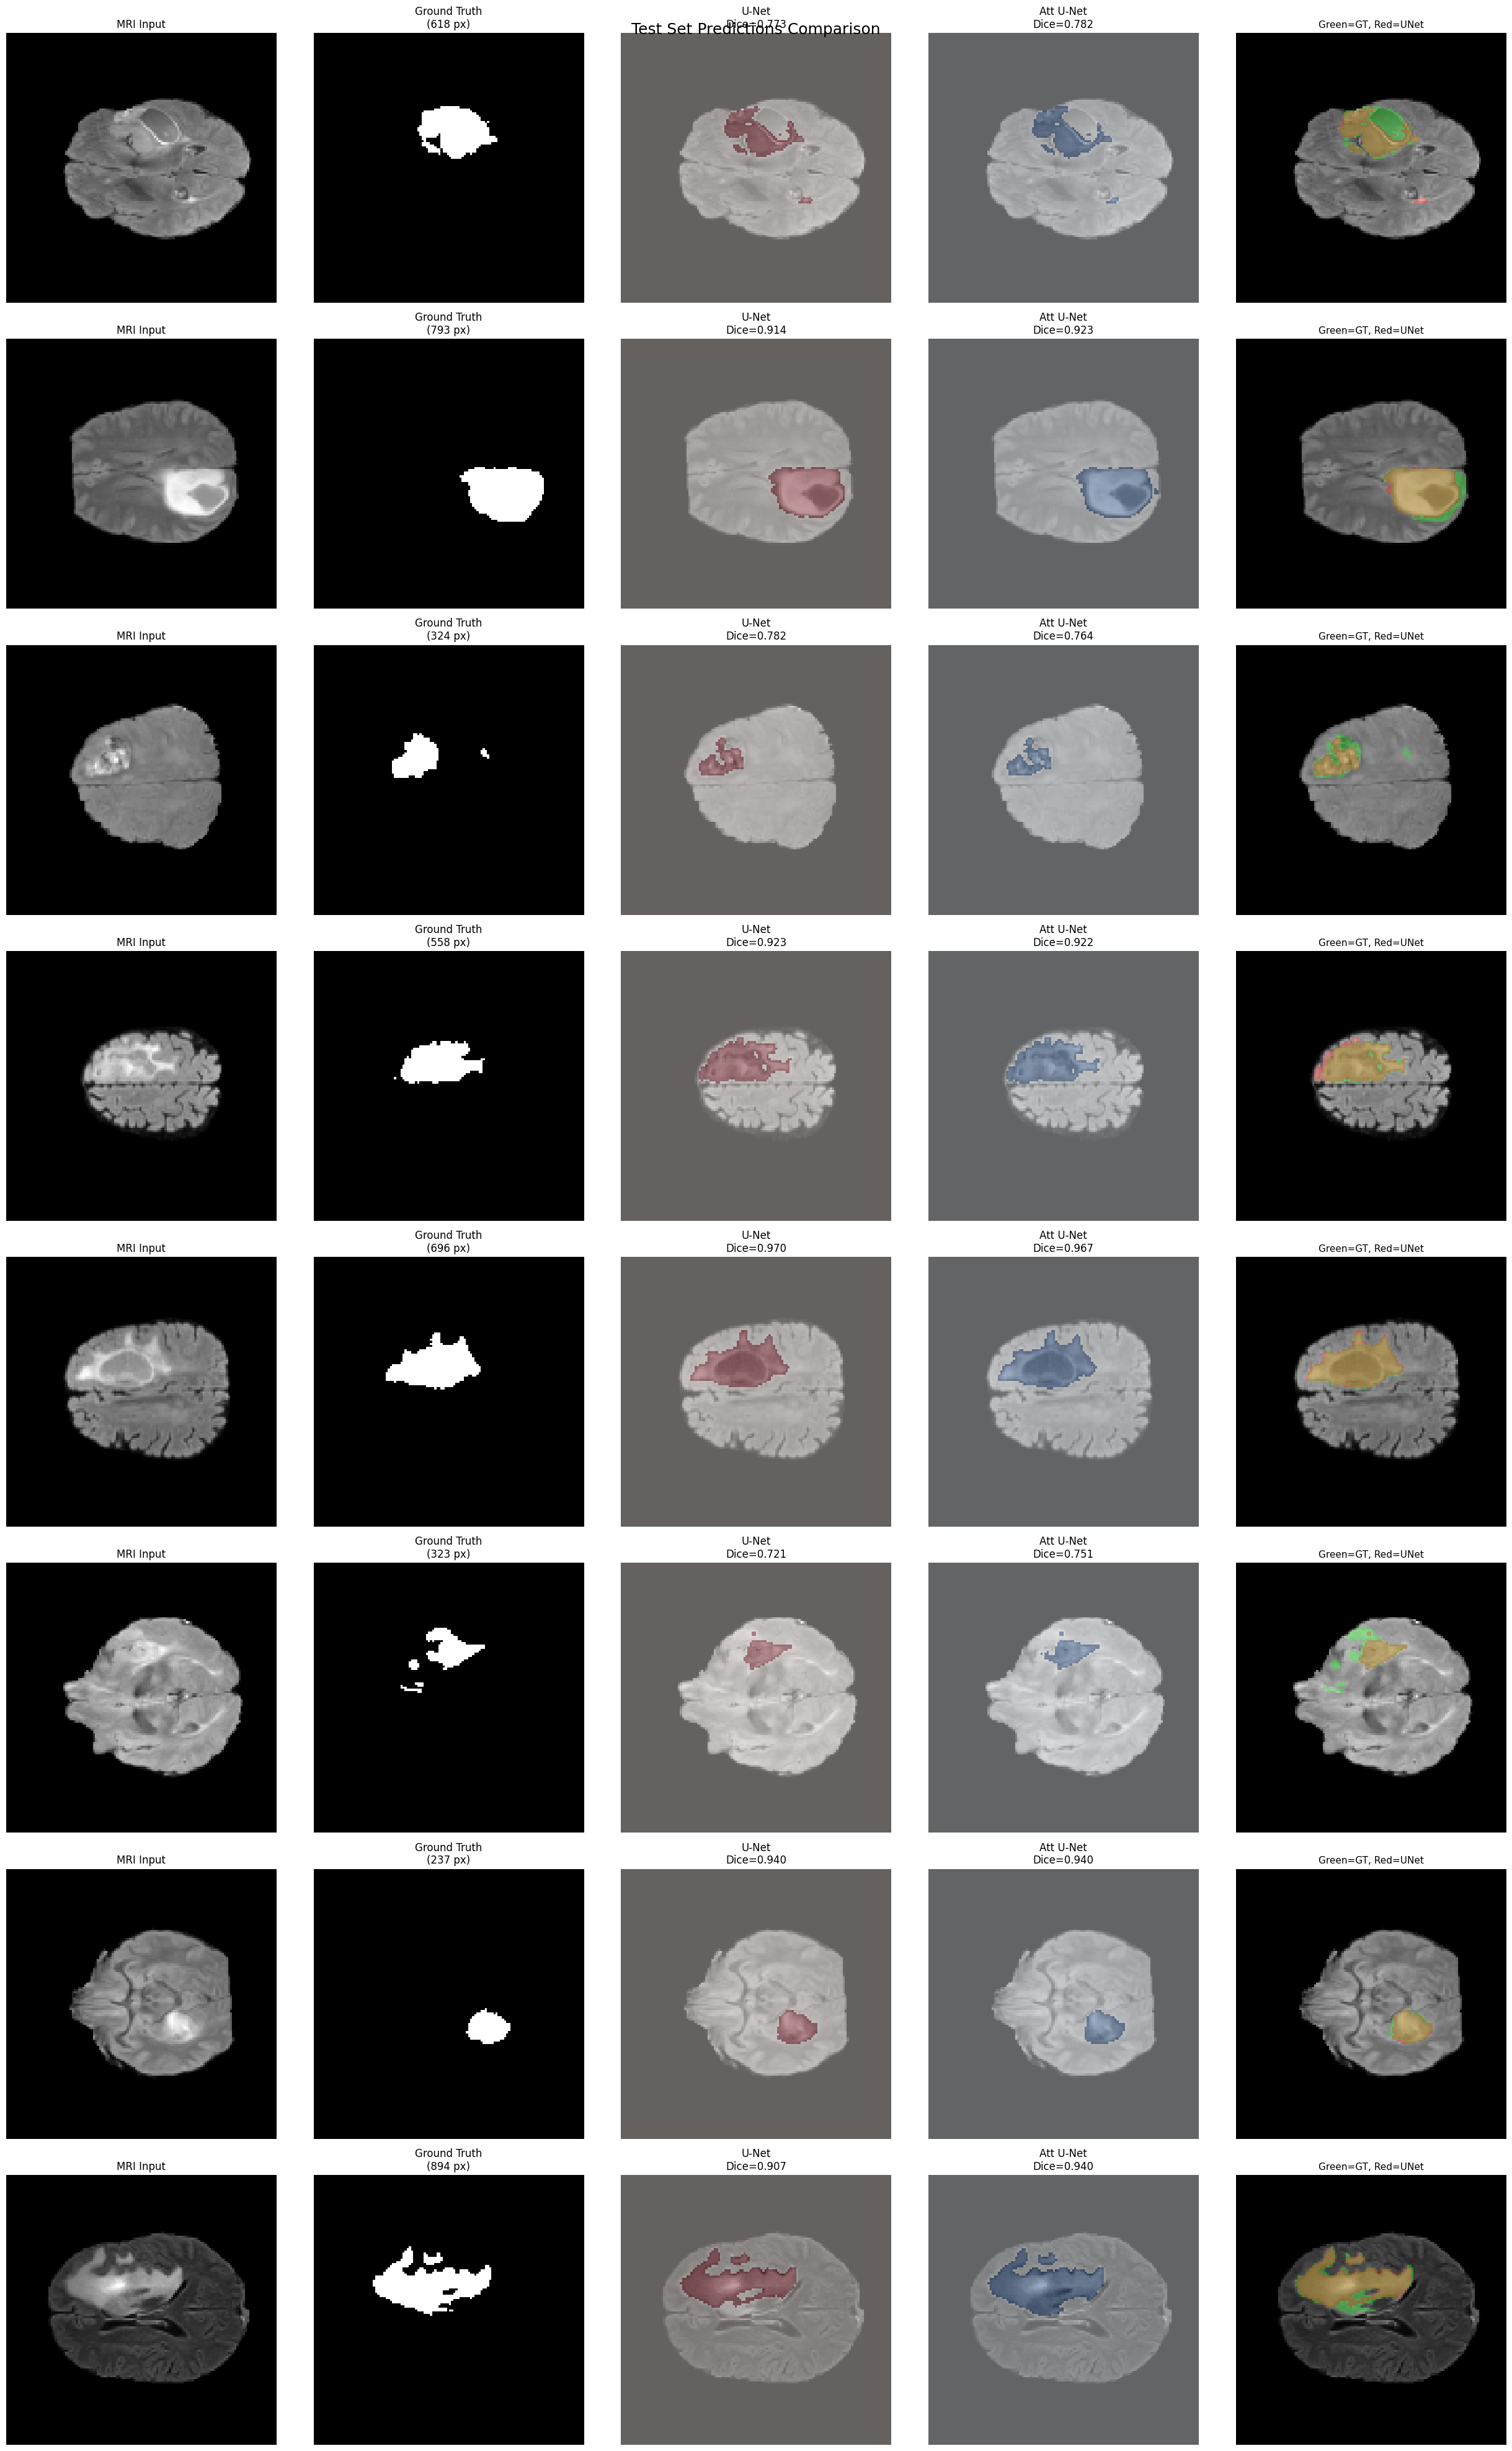

Saved: predictions_comparison.png


In [11]:
# ============================================================
# CELL 10: VISUALIZE TEST PREDICTIONS
# ============================================================

def visualize_predictions(inputs, targets, preds_unet, preds_att, dice_unet, dice_att, n=8):
    """Show side-by-side comparison of predictions"""

    # Find samples WITH tumor for meaningful visualization
    tumor_mask_sums = targets.squeeze(1).reshape(len(targets), -1).sum(dim=1)
    tumor_indices = torch.where(tumor_mask_sums > 100)[0].numpy()

    if len(tumor_indices) < n:
        tumor_indices = torch.where(tumor_mask_sums > 0)[0].numpy()

    np.random.seed(42)
    selected = np.random.choice(tumor_indices, min(n, len(tumor_indices)), replace=False)

    fig, axes = plt.subplots(len(selected), 5, figsize=(25, 5 * len(selected)))

    for row, idx in enumerate(selected):
        img = inputs[idx, 0].numpy()
        gt = targets[idx, 0].numpy()
        pred_u = (preds_unet[idx, 0].numpy() > 0.5).astype(float)
        pred_a = (preds_att[idx, 0].numpy() > 0.5).astype(float)

        # Column 0: MRI
        axes[row, 0].imshow(img, cmap='gray')
        axes[row, 0].set_title('MRI Input', fontsize=12)
        axes[row, 0].axis('off')

        # Column 1: Ground Truth
        axes[row, 1].imshow(gt, cmap='gray')
        axes[row, 1].set_title(f'Ground Truth\n({int(gt.sum())} px)', fontsize=12)
        axes[row, 1].axis('off')

        # Column 2: U-Net prediction
        axes[row, 2].imshow(img, cmap='gray')
        axes[row, 2].imshow(pred_u, cmap='Reds', alpha=0.4)
        axes[row, 2].set_title(f'U-Net\nDice={dice_unet[idx]:.3f}', fontsize=12)
        axes[row, 2].axis('off')

        # Column 3: Attention U-Net prediction
        axes[row, 3].imshow(img, cmap='gray')
        axes[row, 3].imshow(pred_a, cmap='Blues', alpha=0.4)
        axes[row, 3].set_title(f'Att U-Net\nDice={dice_att[idx]:.3f}', fontsize=12)
        axes[row, 3].axis('off')

        # Column 4: Overlay comparison
        axes[row, 4].imshow(img, cmap='gray')

        overlay = np.zeros((*img.shape, 4))
        # Green = Ground truth
        overlay[gt > 0.5] = [0, 1, 0, 0.3]
        axes[row, 4].imshow(overlay)

        overlay2 = np.zeros((*img.shape, 4))
        # Red = U-Net prediction
        overlay2[pred_u > 0.5] = [1, 0, 0, 0.3]
        axes[row, 4].imshow(overlay2)

        axes[row, 4].set_title('Green=GT, Red=UNet', fontsize=11)
        axes[row, 4].axis('off')

    plt.suptitle('Test Set Predictions Comparison', fontsize=18)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/brain_tumor_project/predictions_comparison.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved: predictions_comparison.png")

visualize_predictions(
    unet_inputs, unet_targets,
    unet_preds, att_preds,
    unet_dice_scores, att_dice_scores,
    n=8
)

U-Net dice scores: 890 samples
Attention U-Net dice scores: 890 samples
U-Net mean: 0.7643
Att U-Net mean: 0.7572


/tmp/ipykernel_3328/3078856744.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([unet_scores, att_scores],


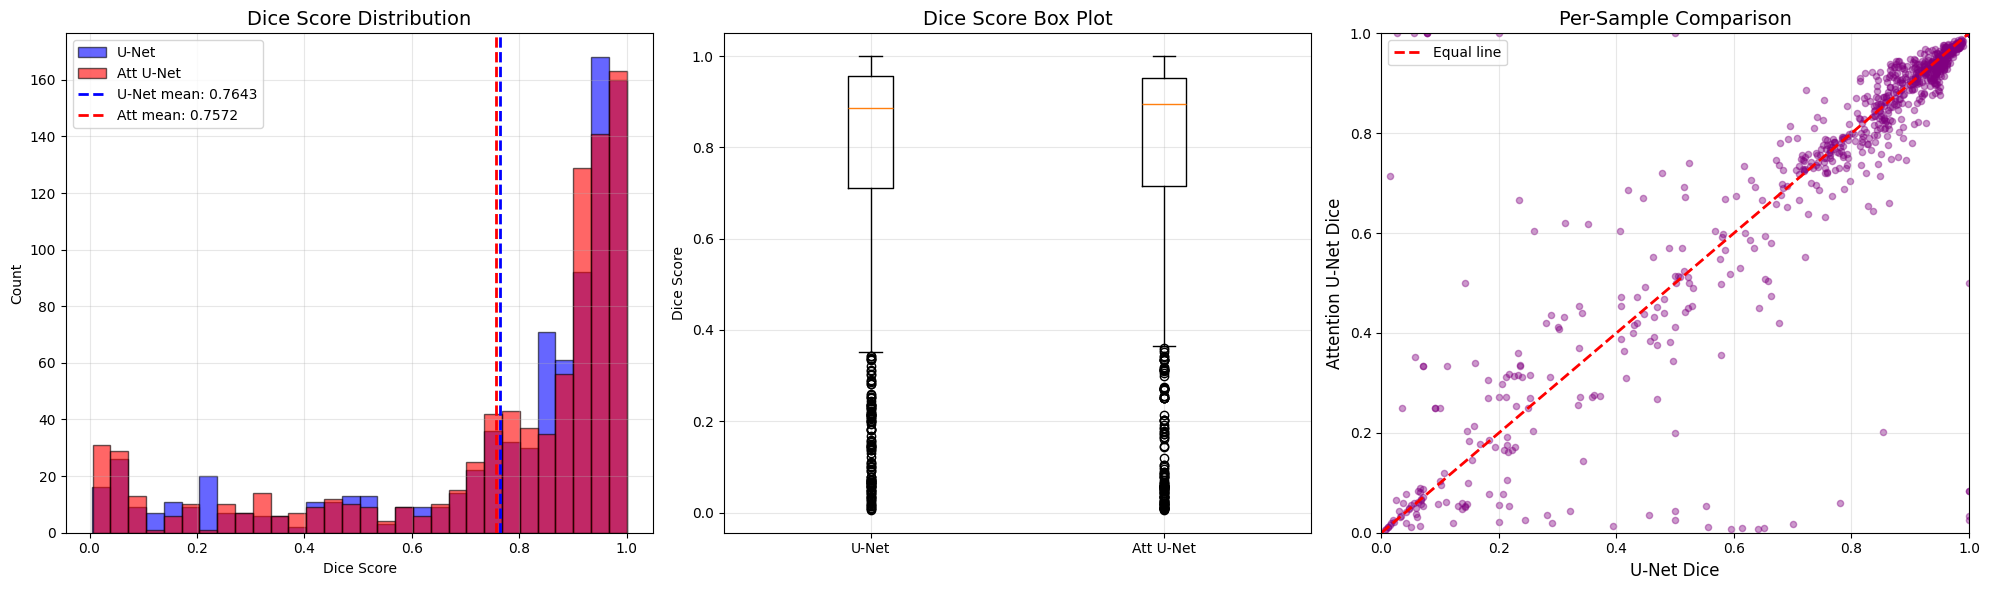


DICE SCORE STATISTICS

U-Net:
  Mean:   0.7643 ± 0.2811
  Median: 0.8852
  Min:    0.0055
  Max:    1.0000
  Excellent (≥0.85):  521 (58.5%)
  Good (0.7-0.85):    151 (17.0%)
  Decent (0.5-0.7):    63 (7.1%)
  Poor (<0.5):        155 (17.4%)

Attention U-Net:
  Mean:   0.7572 ± 0.2900
  Median: 0.8952
  Min:    0.0058
  Max:    1.0000
  Excellent (≥0.85):  513 (57.6%)
  Good (0.7-0.85):    158 (17.8%)
  Decent (0.5-0.7):    56 (6.3%)
  Poor (<0.5):        163 (18.3%)

✅ Saved: dice_distribution.png


In [16]:
# ============================================================
# CELL 11: DICE SCORE DISTRIBUTION (FIXED)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# Check if variables exist from Cell 9
print(f"U-Net dice scores: {len(unet_dice_scores)} samples")
print(f"Attention U-Net dice scores: {len(att_dice_scores)} samples")
print(f"U-Net mean: {np.mean(unet_dice_scores):.4f}")
print(f"Att U-Net mean: {np.mean(att_dice_scores):.4f}")

# Convert to numpy arrays if they aren't already
unet_scores = np.array(unet_dice_scores)
att_scores = np.array(att_dice_scores)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ---- Plot 1: Histogram ----
axes[0].hist(unet_scores, bins=30, alpha=0.6, label='U-Net',
             color='blue', edgecolor='black')
axes[0].hist(att_scores, bins=30, alpha=0.6, label='Att U-Net',
             color='red', edgecolor='black')
axes[0].axvline(x=np.mean(unet_scores), color='blue', linestyle='--',
                linewidth=2, label=f'U-Net mean: {np.mean(unet_scores):.4f}')
axes[0].axvline(x=np.mean(att_scores), color='red', linestyle='--',
                linewidth=2, label=f'Att mean: {np.mean(att_scores):.4f}')
axes[0].set_title('Dice Score Distribution', fontsize=14)
axes[0].set_xlabel('Dice Score')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ---- Plot 2: Box Plot ----
axes[1].boxplot([unet_scores, att_scores],
                labels=['U-Net', 'Att U-Net'])
axes[1].set_title('Dice Score Box Plot', fontsize=14)
axes[1].set_ylabel('Dice Score')
axes[1].grid(True, alpha=0.3)

# ---- Plot 3: Scatter ----
min_len = min(len(unet_scores), len(att_scores))
axes[2].scatter(unet_scores[:min_len], att_scores[:min_len],
                alpha=0.4, s=20, color='purple')
axes[2].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Equal line')
axes[2].set_xlabel('U-Net Dice', fontsize=12)
axes[2].set_ylabel('Attention U-Net Dice', fontsize=12)
axes[2].set_title('Per-Sample Comparison', fontsize=14)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/brain_tumor_project/dice_distribution.png',
            dpi=200, bbox_inches='tight')
plt.show()

# ---- Print Statistics ----
print(f"\n{'='*60}")
print(f"DICE SCORE STATISTICS")
print(f"{'='*60}")

for name, scores in [("U-Net", unet_scores), ("Attention U-Net", att_scores)]:
    excellent = np.sum(scores >= 0.85)
    good = np.sum((scores >= 0.7) & (scores < 0.85))
    decent = np.sum((scores >= 0.5) & (scores < 0.7))
    poor = np.sum(scores < 0.5)

    print(f"\n{name}:")
    print(f"  Mean:   {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    print(f"  Median: {np.median(scores):.4f}")
    print(f"  Min:    {np.min(scores):.4f}")
    print(f"  Max:    {np.max(scores):.4f}")
    print(f"  Excellent (≥0.85): {excellent:4d} ({excellent/len(scores)*100:.1f}%)")
    print(f"  Good (0.7-0.85):   {good:4d} ({good/len(scores)*100:.1f}%)")
    print(f"  Decent (0.5-0.7):  {decent:4d} ({decent/len(scores)*100:.1f}%)")
    print(f"  Poor (<0.5):       {poor:4d} ({poor/len(scores)*100:.1f}%)")

print(f"\n✅ Saved: dice_distribution.png")

In [17]:
# ============================================================
# CELL 12: SAVE TRAINED MODELS TO GOOGLE DRIVE
# ============================================================
import torch
import os
import json

SAVE_BASE = "/content/drive/MyDrive/brain_tumor_project"

# ---- Save U-Net ----
unet_save_dir = os.path.join(SAVE_BASE, "final_models")
os.makedirs(unet_save_dir, exist_ok=True)

# Save complete model info
torch.save({
    'model_name': 'UNet',
    'model_state_dict': trained_unet.state_dict(),
    'features': [64, 128, 256, 512],
    'in_channels': 1,
    'out_channels': 1,
    'best_val_dice': 0.8106,
    'test_dice': unet_results['dice_mean'],
    'test_iou': unet_results['iou_mean'],
    'test_precision': unet_results['precision_mean'],
    'test_recall': unet_results['recall_mean'],
}, os.path.join(unet_save_dir, "unet_best_model.pth"))

print(f"✅ U-Net saved to: {unet_save_dir}/unet_best_model.pth")

# ---- Save Attention U-Net ----
torch.save({
    'model_name': 'AttentionUNet',
    'model_state_dict': trained_att.state_dict(),
    'features': [64, 128, 256, 512],
    'in_channels': 1,
    'out_channels': 1,
    'best_val_dice': 0.8181,
    'test_dice': att_results['dice_mean'],
    'test_iou': att_results['iou_mean'],
    'test_precision': att_results['precision_mean'],
    'test_recall': att_results['recall_mean'],
}, os.path.join(unet_save_dir, "attention_unet_best_model.pth"))

print(f"✅ Attention U-Net saved to: {unet_save_dir}/attention_unet_best_model.pth")

# ---- Save Results Summary ----
results_summary = {
    'UNet': {
        'best_val_dice': 0.8106,
        'test_dice': float(unet_results['dice_mean']),
        'test_dice_std': float(unet_results['dice_std']),
        'test_iou': float(unet_results['iou_mean']),
        'test_precision': float(unet_results['precision_mean']),
        'test_recall': float(unet_results['recall_mean']),
        'test_accuracy': float(unet_results['accuracy_mean']),
        'training_time_min': 40.7,
        'epochs_trained': 35,
    },
    'AttentionUNet': {
        'best_val_dice': 0.8181,
        'test_dice': float(att_results['dice_mean']),
        'test_dice_std': float(att_results['dice_std']),
        'test_iou': float(att_results['iou_mean']),
        'test_precision': float(att_results['precision_mean']),
        'test_recall': float(att_results['recall_mean']),
        'test_accuracy': float(att_results['accuracy_mean']),
        'training_time_min': 56.5,
        'epochs_trained': 43,
    }
}

with open(os.path.join(unet_save_dir, "results_summary.json"), 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"✅ Results summary saved!")

# ---- Verify saved files ----
print(f"\n{'='*60}")
print(f"ALL SAVED FILES:")
print(f"{'='*60}")

for root, dirs, files in os.walk(SAVE_BASE):
    for f in sorted(files):
        fpath = os.path.join(root, f)
        size = os.path.getsize(fpath) / (1024 * 1024)
        relative = fpath.replace(SAVE_BASE, "")
        print(f"  📄 {relative:50s} {size:.1f} MB")

print(f"\n{'='*60}")
print(f"✅ EVERYTHING SAVED TO GOOGLE DRIVE!")
print(f"{'='*60}")


✅ U-Net saved to: /content/drive/MyDrive/brain_tumor_project/final_models/unet_best_model.pth
✅ Attention U-Net saved to: /content/drive/MyDrive/brain_tumor_project/final_models/attention_unet_best_model.pth
✅ Results summary saved!

ALL SAVED FILES:
  📄 /attention_unet_trained.pth                        119.9 MB
  📄 /dice_distribution.png                             0.3 MB
  📄 /predictions_comparison.png                        0.7 MB
  📄 /results_summary.json                              0.0 MB
  📄 /training_curves.png                               0.4 MB
  📄 /unet_trained.pth                                  118.5 MB
  📄 /processed/metadata.pkl                            0.1 MB
  📄 /processed/test_images.npy                         55.6 MB
  📄 /processed/test_masks.npy                          55.6 MB
  📄 /processed/train_images.npy                        248.3 MB
  📄 /processed/train_masks.npy                         248.3 MB
  📄 /processed/val_images.npy                          53

In [18]:
# ============================================================
# CELL 13: FINAL PROJECT SUMMARY
# ============================================================

print(f"""
{'='*70}
🎯 BRAIN TUMOR SEGMENTATION — PROJECT COMPLETE
{'='*70}

📊 FINAL RESULTS:
{'─'*70}
{'Metric':<30} {'U-Net':<20} {'Attention U-Net':<20}
{'─'*70}
{'Parameters':<30} {'31,037,633':<20} {'34,877,249':<20}
{'Training Epochs':<30} {'35':<20} {'43':<20}
{'Training Time':<30} {'40.7 min':<20} {'56.5 min':<20}
{'Best Val Dice':<30} {'0.8106':<20} {'0.8181 🏆':<20}
{'Test Dice':<30} {unet_results['dice_mean']:<20.4f} {att_results['dice_mean']:<20.4f}
{'Test IoU':<30} {unet_results['iou_mean']:<20.4f} {att_results['iou_mean']:<20.4f}
{'Test Precision':<30} {unet_results['precision_mean']:<20.4f} {att_results['precision_mean']:<20.4f}
{'Test Recall':<30} {unet_results['recall_mean']:<20.4f} {att_results['recall_mean']:<20.4f}
{'Test Accuracy':<30} {unet_results['accuracy_mean']:<20.4f} {att_results['accuracy_mean']:<20.4f}
{'─'*70}

📁 FILES IN GOOGLE DRIVE (brain_tumor_project/):
   ├── train_images.npy, train_masks.npy
   ├── val_images.npy, val_masks.npy
   ├── test_images.npy, test_masks.npy
   ├── final_models/
   │   ├── unet_best_model.pth
   │   ├── attention_unet_best_model.pth
   │   └── results_summary.json
   ├── dice_distribution.png
   └── training_curves.png

✅ NEXT STEPS:
   1. Download model files from Google Drive to your local PC
   2. Place them in checkpoints/ folder
   3. Run Streamlit GUI locally
   4. Tell me "models downloaded" for the GUI code
{'='*70}
""")


🎯 BRAIN TUMOR SEGMENTATION — PROJECT COMPLETE

📊 FINAL RESULTS:
──────────────────────────────────────────────────────────────────────
Metric                         U-Net                Attention U-Net     
──────────────────────────────────────────────────────────────────────
Parameters                     31,037,633           34,877,249          
Training Epochs                35                   43                  
Training Time                  40.7 min             56.5 min            
Best Val Dice                  0.8106               0.8181 🏆            
Test Dice                      0.7643               0.7572              
Test IoU                       0.6884               0.6826              
Test Precision                 0.8675               0.8681              
Test Recall                    0.7729               0.7725              
Test Accuracy                  0.9897               0.9896              
───────────────────────────────────────────────────────────────